In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from pykalman import KalmanFilter
from hurst import compute_Hc
from statsmodels.tsa.vector_ar.vecm import VECM, select_order
import time
from IPython.display import clear_output

In [125]:
JANELA_Z = 60
log=False

In [126]:
def get_values(y, x, window):
    if(window <= 0):
        return y, x
    
    y = y.iloc[:window]
    x = x.iloc[:window]
    return y, x

def zscore(resid, window=120):
    #return (resid - resid.rolling(window).mean()) / resid.rolling(window).std()
    return (resid - resid.mean()) / resid.std()

def regression(y, x, window):
    y_cut, x_cut = get_values(y, x, window)
    pairs = pd.DataFrame({"y": y_cut, "x": x_cut})
    X = sm.add_constant(pairs["x"])

    model = sm.OLS(pairs["y"], X).fit()
    return model
    
class PairKalman:
    def __init__(self):

        self.delta=1e-5

        trans_cov = (self.delta / (1 - self.delta)) * np.eye(2)

        self.kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.zeros(2),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_covariance=1.0,
            transition_covariance=trans_cov,
        )

        # estado atual do filtro
        self.state_mean = np.zeros(2)
        self.state_cov = np.eye(2)

        self.history = []
            
    def fit(self, y, x):
        obs_mat = np.vstack([x.values, np.ones(len(x))]).T[:, np.newaxis, :]
        self.kf.observation_matrices = obs_mat
        state_means, state_covs = self.kf.filter(y.values)

        self.state_mean = state_means[-1]
        self.state_cov = state_covs[-1]

        beta = state_means[:, 0]
        alpha = state_means[:, 1]

        resid = y.values - (beta * x.values + alpha)

        for i in range(len(y)):
            self.history.append(
                {
                    #"date": df["date"].iloc[i],
                    "beta": beta[i],
                    "alpha": alpha[i],
                    "resid": resid[i],
                }
            )

        return self.dataframe()

    def update(self, y, x, date=None):
        obs_matrix = np.array([[x, 1.0]])

        self.state_mean, self.state_cov = self.kf.filter_update(
            filtered_state_mean=self.state_mean,
            filtered_state_covariance=self.state_cov,
            observation=y,
            observation_matrix=obs_matrix,
            transition_offset=np.zeros(2),
            observation_offset=np.zeros(1),
        )

        beta = self.state_mean[0]
        alpha = self.state_mean[1]

        resid = y - (beta * x + alpha)

        result = {
            
            #"date": date,
            "beta": beta,
            "alpha": alpha,
            "resid": resid,
        }

        self.history.append(result)
        return result

    def dataframe(self):
        return pd.DataFrame(self.history)

    @property
    def beta(self):
        return self.state_mean[0]

    @property
    def alpha(self):
        return self.state_mean[1]
        
def dickey_fuller(resid, window=250):
    #if len(resid) >= window:
     #   resid = resid[-window:]
    
    model = ts.adfuller(resid, autolag="AIC")

    statistic = model[0]
    p_value = model[1]
    crit_vals = model[4]

    # estacionária se o p-valor for menor que 5% (0.05)
    is_stationary = p_value < 0.05

    # quanto MENOR (mais negativo) o número, MAIOR é a confiança
    perc_stat = 0
    if statistic < crit_vals["1%"]:
        perc_stat = 99
    elif statistic < crit_vals["5%"]:
        perc_stat = 95
    elif statistic < crit_vals["10%"]:
        perc_stat = 90

    return {
        "is_stationary": is_stationary,
        "p-value": p_value,
        "confidence_level": perc_stat,
        "statistic": statistic,
    }

def compute_half_life(resid, window=500):
    """Calcula a Meia-Vida (Half-Life) de reversão à média de uma série.

    Retorna o número de candles (int) ou np.inf se a série for
    não-estacionária.
    """
    #if len(resid) > window:
        #resid = resid[-window:]
            
    # garante que seja Pandas Series
    resid = pd.Series(resid).dropna()

    # cria a variável defasada (Lag) e a diferença (Retorno/Variação)
    lag = resid.shift(1)
    delta = resid - lag

    # remove o primeiro valor (que virou NaN devido ao shift)
    df_reg = pd.DataFrame({"delta": delta, "lag": lag}).dropna()

    if len(df_reg) < 10:
        return np.inf  # Histórico insuficiente

    # adiciona a constante (intercepto) e ajusta a regressão OLS
    X = sm.add_constant(df_reg["lag"])
    y = df_reg["delta"]

    model = sm.OLS(y, X).fit()

    # o coeficiente do 'lag' é a taxa de reversão (lambda)
    lambda_coef = model.params["lag"]

    # se lambda >= 0, a série é neutra ou em tendência (não reverte à média)
    if lambda_coef >= 0:
        return np.inf
        
    # cálculo do Half-Life: -ln(2) / lambda
    half_life = -np.log(2) / lambda_coef

    #return int(np.round(half_life))
    return float(half_life)

def prepare_values(y, x):
    y = y.copy()
    x = x.copy()

    if log == True:
        y = np.log(y)
        x = np.log(x)
        #y = np.log(y / y.shift(1))
        #x = np.log(x / x.shift(1))

    return y, x
    
def fit_vecm_pair(y, x, max_lags=5, window=500):
    """Ajusta o Modelo VECM para um par de ativos e extrai os parâmetros de

    reversão.

    Retorna um dicionário com Beta, Alphas, Residuo Atual e Status.
    """
    #if len(y) > window:
        #y = y[-window:]
        #x = x[-window:]
            
    # 1. Prepara a matriz dos preços
    df_pair = pd.concat([y, x], axis=1).dropna()
    df_pair.columns = ["Asset_1", "Asset_2"]

    if len(df_pair) < 50:
        return {"success": False, "error": "Histórico insuficiente (< 50)"}

    try:
        # 2. Seleção automática da quantidade ideal de Lags (AIC)
        lag_order = select_order(df_pair, maxlags=max_lags, deterministic="ci")
        k_ar_diff = max(1, lag_order.aic)

        # 3. Ajuste do modelo VECM com rank de cointegração = 1
        model = VECM(
            df_pair, k_ar_diff=k_ar_diff, coint_rank=1, deterministic="ci"
        )
        vecm_res = model.fit()

        # 4. Extração do Vetor Beta (normalizado para o primeiro ativo = 1.0)
        beta_raw = vecm_res.beta[:, 0]
        beta_asset_1 = 1.0
        beta_asset_2 = beta_raw[1] / beta_raw[0]

        # 5. Extração da Velocidade de Ajuste (Alphas)
        alpha_asset_1 = vecm_res.alpha[0, 0]
        alpha_asset_2 = vecm_res.alpha[1, 0]

        # 6. Cálculo da série do Resíduo (ECT - Error Correction Term)
        # ECT = Asset_1 - (Beta * Asset_2)
        ect_series = df_pair["Asset_1"] + (beta_asset_2 * df_pair["Asset_2"])

        return {
            "success": True,
            "beta": float(beta_asset_2),  # Beta do Asset_2 em relação ao Asset_1
            "alpha_1": float(alpha_asset_1),  # Velocidade de ajuste do Asset_1
            "alpha_2": float(alpha_asset_2),  # Velocidade de ajuste do Asset_2
            #"ect_series": ect_series,  # Série temporal do resíduo/spread
            #"current_ect": float(ect_series.iloc[-1]),  # Último resíduo (candle atual)
            "lags_used": int(k_ar_diff),
        }

    except Exception as e:
        return {"success": False, "error": str(e)}

def plot_residue(
    resid,
    desv_input=2,
    padronizar=True,
    y_symbol="",
    x_symbol="",
    inverter_ordem=False,
):
    """Plota o resíduo da regressão com faixas de desvio padrão/Z-Score."""
    # 1. Ajuste de ordem temporal se necessário
    if inverter_ordem:
        resid = resid[::-1]
        
    media = 0.0
    std = 1.0
    
    # 2. Padronização (Z-Score)
    if padronizar:
        resid = zscore(resid)
        ylabel = "Desvios Padrão (Z-Score)"
    else:
        ylabel = "Resíduo Bruto"
        media = resid.mean()
        std = resid.std()
    
    # 3. Plot da Linha Principal
    plt.figure(figsize=(17, 6))
    plt.plot(resid.index, resid, linewidth=2, label="Resíduo", color="#1f77b4")
    
    # 4. Título e Rótulos
    if y_symbol != "" and x_symbol != "":
        plt.title(
            f"Análise de Resíduos: {y_symbol} / {x_symbol}",
            fontsize=14,
            fontweight="bold",
        )
    else:
        plt.title("Análise de Resíduos", fontsize=14, fontweight="bold")

    plt.ylabel(ylabel, fontsize=11)
    plt.grid(True, linestyle="--", alpha=0.5)

    # 5. Linhas de Referência (Média e Desvios)
    plt.axhline(
        media,
        color="black",
        linestyle="-",
        linewidth=1.2,
        label=f"Média ({media:.2f})",
    )
    plt.axhline(
        desv_input * std,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"+{desv_input} Std Dev",
    )
    plt.axhline(
        -desv_input * std,
        color="green",
        linestyle="--",
        linewidth=2,
        label=f"-{desv_input} Std Dev",
    )

    # 6. Sombra de Destaque para as zonas extremas
    plt.fill_between(
        resid.index,
        desv_input * std,
        resid,
        where=(resid >= desv_input * std),
        color="red",
        alpha=0.2,
    )
    plt.fill_between(
        resid.index,
        -desv_input * std,
        resid,
        where=(resid <= -desv_input * std),
        color="green",
        alpha=0.2,
    )

    plt.legend(loc="upper left")
    plt.tight_layout()
    plt.show()

def compute_hurst_rs(series, window=None):
    """
    Hurst pelo método clássico R/S (Rescaled Range).
    """

    if window and len(series) > window:
        series = series[-window:]

    x = np.asarray(series, dtype=float)
    n = len(x)

    if n < 20 or np.std(x) == 0:
        return 0.5

    max_lag = min(n // 10, 500)

    lags = np.unique(
        np.logspace(
            np.log10(8),
            np.log10(max_lag),
            num=30,
            dtype=int,
        )
    )

    rs = []

    valid_lags = []

    for lag in lags:

        chunks = n // lag

        if chunks < 2:
            continue

        values = []

        for i in range(chunks):

            chunk = x[i * lag : (i + 1) * lag]

            y = chunk - chunk.mean()

            z = np.cumsum(y)

            R = z.max() - z.min()

            S = chunk.std(ddof=1)

            if S > 0:
                values.append(R / S)

        if values:
            rs.append(np.mean(values))
            valid_lags.append(lag)

    if len(valid_lags) < 2:
        return 0.5

    H = np.polyfit(np.log(valid_lags), np.log(rs), 1)[0]

    return float(np.clip(H, 0, 1))

def compute_hurst(series, window=None):
    """
    Hurst pelo método Variance-Time.
    """
    if window and len(series) > window:
        series = series[-window:]

    x = np.asarray(series, dtype=float)
    n = len(x)

    if n < 50:
        return 0.5

    max_lag = min(n // 10, 500)

    lags = np.unique(
        np.logspace(
            np.log10(2),
            np.log10(max_lag),
            num=30,
            dtype=int,
        )
    )

    vars = []
    valid = []

    for lag in lags:
        m = n // lag
        if m < 2:
            continue
            
        blocks = x[: m * lag].reshape(m, lag)
        means = blocks.mean(axis=1)
        v = np.var(means)

        if v > 0:
            vars.append(v)
            valid.append(lag)

    if len(valid) < 2:
        return 0.5

    slope = np.polyfit(np.log(valid), np.log(vars), 1)[0]
    H = 1 + slope / 2

    return float(np.clip(H, 0, 1))

In [156]:
win_file = "dados\\win_M5.csv"
wdo_file = "dados\\wdo_M5.csv"

#win_file = "dados\\WIN_M1.csv"
#wdo_file = "dados\\WDO_M1.csv"

#win_file = "dados\\WIN_M15.csv"
#wdo_file = "dados\\WDO_M15.csv"

#win_file = "dados\\WIN_D.csv"
#wdo_file = "dados\\WDO_D.csv"

df_win = pd.read_csv(win_file, sep="\t")[["<DATE>", "<TIME>", "<CLOSE>"]].rename(
    columns={"<DATE>": "date", "<TIME>": "time", "<CLOSE>": "WIN"}
)
df_wdo = pd.read_csv(wdo_file, sep="\t")[["<DATE>", "<TIME>", "<CLOSE>"]].rename(
    columns={"<DATE>": "date", "<TIME>": "time", "<CLOSE>": "WDO"}
)

df_win["date"] = pd.to_datetime(df_win["date"] + " " + df_win["time"])
df_wdo["date"] = pd.to_datetime(df_wdo["date"] + " " + df_wdo["time"])

#df_win = df_win.iloc[::-1].reset_index(drop=True)
#df_wdo = df_wdo.iloc[::-1].reset_index(drop=True)

In [157]:
index = 9

df = pd.merge(df_win[["date", "WIN"]], df_wdo[["date", "WDO"]], on="date").dropna()

fim = len(df) - index
inicio = fim - JANELA_Z
#df = df.iloc[inicio:fim].reset_index(drop=True)
#df = df.iloc[-JANELA_Z:].reset_index(drop=True)

In [158]:
y = 'WDO'
x = 'WIN'

In [159]:
#model = run_pykalman(df[y], df[x])
y_values, x_values = prepare_values(df[y], df[x])

kalman = PairKalman()
model = kalman.fit(y_values, x_values)
resid = model['resid']
#model

In [160]:
adf_res = dickey_fuller(resid)
print(adf_res)

if adf_res["is_stationary"]:
    print("🟢 O PAR ESTÁ COINTEGRADO! O resíduo é estacionário e pode ser operado.")
else:
    print("🔴 NÃO COINTEGRADO! O resíduo tem tendência e NÃO deve ser operado.")

{'is_stationary': True, 'p-value': 0.0, 'confidence_level': 99, 'statistic': np.float64(-27.28039665840569)}
🟢 O PAR ESTÁ COINTEGRADO! O resíduo é estacionário e pode ser operado.


In [161]:
z_score = zscore(resid)
last = z_score.iloc[-1]

if last >= 2.0:
    print(f"🟢 SINAL DE VENDA! Z-Score esticado no topo ({last:.2f} >= +2.0).")
elif last <= -2.0:
    print(f"🟢 SINAL DE COMPRA! Z-Score esticado no fundo ({last:.2f} <= -2.0).")
else:
    print(f"⚪ NEUTRO. Z-Score dentro da banda normal ({last:.2f}).")
#z_score

⚪ NEUTRO. Z-Score dentro da banda normal (-0.20).


In [162]:
h_value = compute_hurst(resid)
print(h_value)
if h_value < 0.5:
    print("🟢 Excelente! Série Anti-persistente (Reversão à Média).")
else:
    print("🔴 Atenção! Série em Tendência ou Passeio Aleatório.")

0.4866272057798514
🟢 Excelente! Série Anti-persistente (Reversão à Média).


In [163]:
hl = compute_half_life(resid)
print(hl)

if hl != np.inf:
    print(f"🟢 Half-Life de {hl} candles. Tempo estimado para o resíduo voltar à média.")
else:
    print("🔴 Série sem reversão à média detectada! O resíduo está em tendência.")

0.6208452127323173
🟢 Half-Life de 0.6208452127323173 candles. Tempo estimado para o resíduo voltar à média.


In [164]:
#Para o seu robô de Pairs Trading, apenas o valor NEGATIVO ($-1.0$) 
vecm_data = fit_vecm_pair(df[y], df[x])

if vecm_data["success"]:
    print(f"✅ VECM Ajustado com Sucesso! (Lags: {vecm_data['lags_used']})")
    print(f"📍 Beta do Pair: {vecm_data['beta']:.4f}")
    print(f"⚡ Speed Alpha WIN: {vecm_data['alpha_1']:.4f}")
    print(f"⚡ Speed Alpha WDO: {vecm_data['alpha_2']:.4f}")
    #print(f"📊 Resíduo Atual (ECT): {vecm_data['current_ect']:.4f}")

    # Interpretando a Velocidade de Ajuste
    # Quanto mais negativo o Alpha_1, mais forte o Asset_1 busca a média
    if abs(vecm_data["alpha_1"]) > 0.05:
        print("🟢 O Ativo 1 tem excelente força de retorno à média!")
else:
    print(f"❌ Erro ao ajustar VECM: {vecm_data['error']}")

✅ VECM Ajustado com Sucesso! (Lags: 1)
📍 Beta do Pair: 0.0014
⚡ Speed Alpha WIN: -0.0180
⚡ Speed Alpha WDO: -0.1791


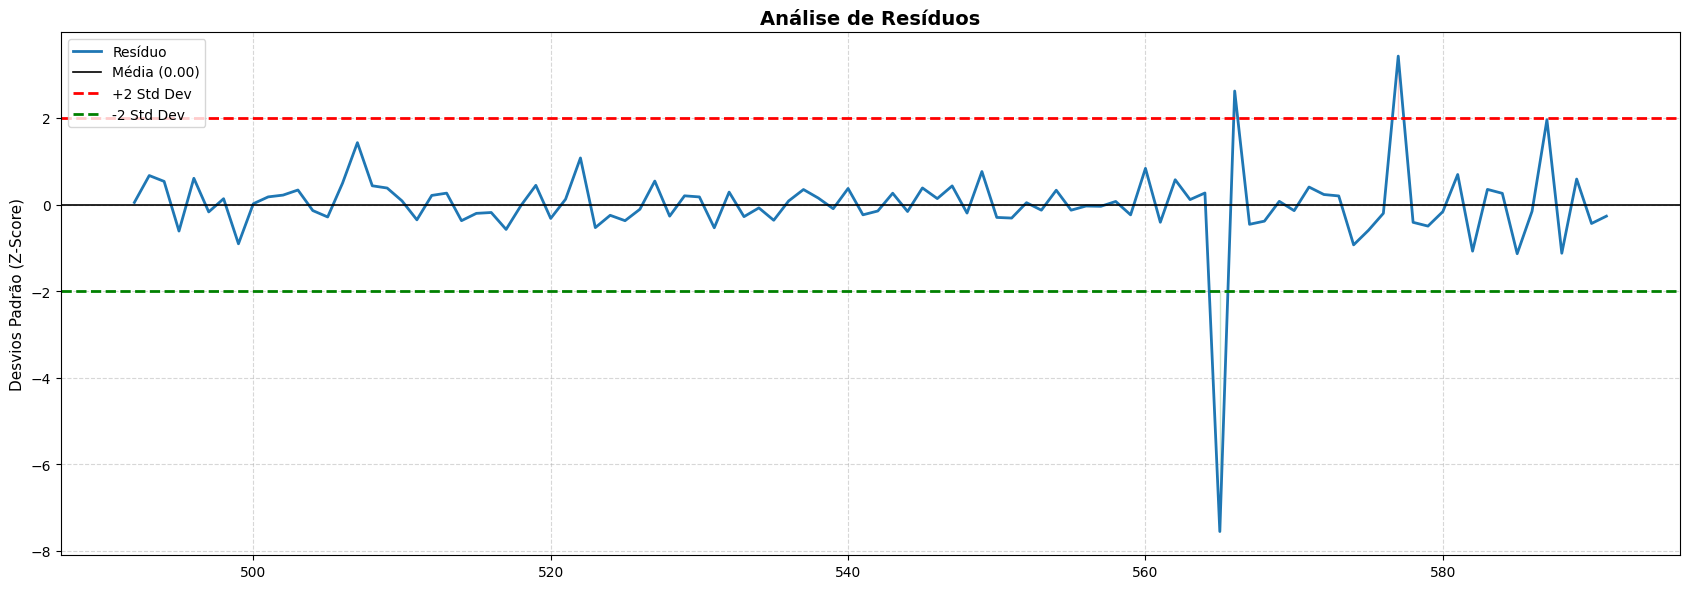

2026-07-20 09:00:00
2026-07-27 11:10:00
592


In [165]:
plot_residue(
    resid[-100:],
    desv_input=2,
    padronizar=True
)

print(df['date'].iloc[0])
print(df['date'].iloc[-1])
print(len(df))

In [168]:
INTERVALO_SEGUNDOS = 0.3  # Tempo de espera entre candles (segundos)
CANDLES_PARA_RODAR = 200  # Quantos candles quer simular andando para frente

total_linhas = len(df)
inicio_replay = total_linhas - CANDLES_PARA_RODAR

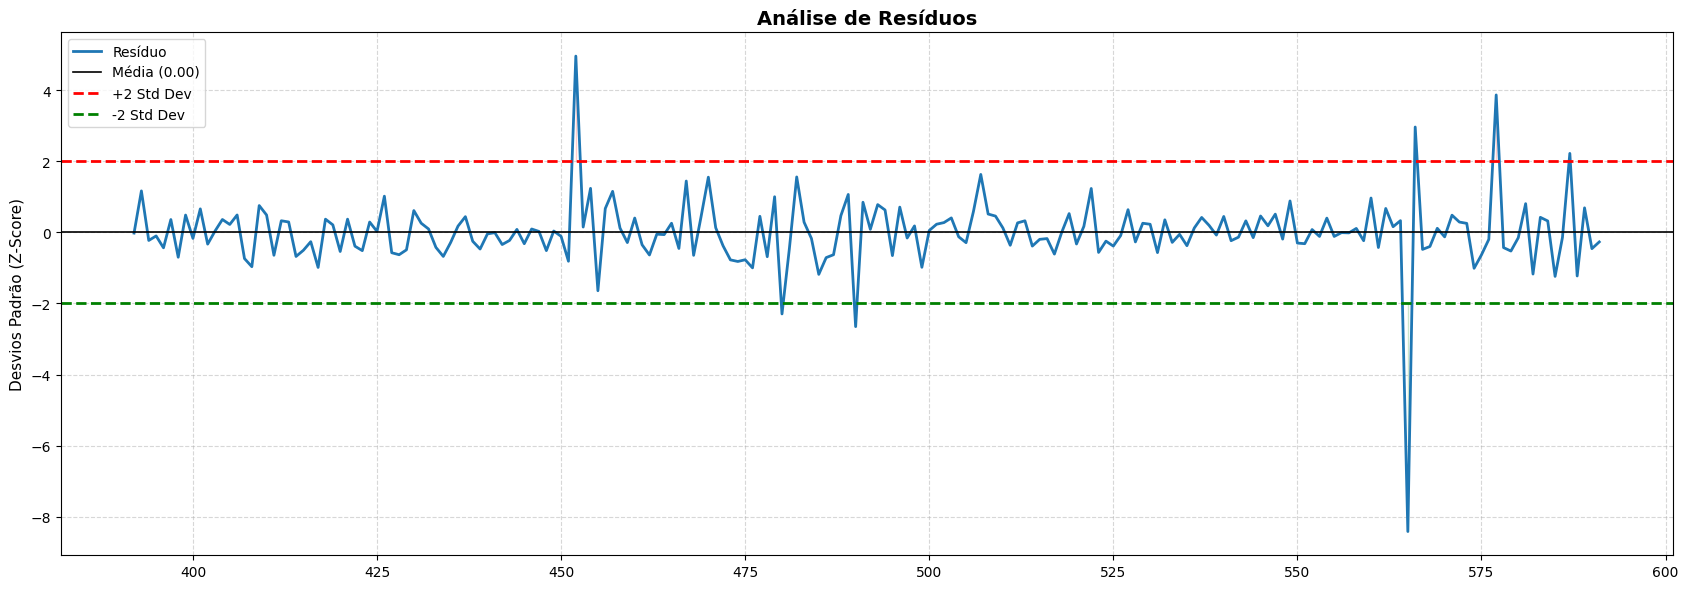

Num: 200 | Candle: 2026-07-27 11:10:00 | Beta: 0.029085508397248383 | Resíduo: -3.987888703704812e-06


In [169]:
kalman = PairKalman()
num = 0
y_values, x_values = prepare_values(df[y].iloc[:inicio_replay], df[x].iloc[:inicio_replay])
df_historico = kalman.fit(y_values, x_values)

operacoes = []
life = []
operacao = None

for i in range(inicio_replay, total_linhas):
    y_atual = df[y].iloc[i]
    x_atual = df[x].iloc[i]
    
    y_values, x_values = prepare_values(y_atual, x_atual)
    resultado_candle = kalman.update(y=y_values, x=x_values)
    
    # C. Pega os últimos 60 candles do histórico acumulado na classe
    df_history = kalman.dataframe()
    janela = df_history.iloc[-200:]

    resid = janela["resid"]
    z = zscore(resid, window=120).iloc[-1]

    # -----------------------------
    # Detecta uma nova operação
    # -----------------------------
    if operacao is None and abs(z) >= 2:
        operacao = {
            "z0": abs(z),
            "inicio": i
        }
        print(f"Entrada: Z={z:.2f}")
    # -----------------------------
    # Mede a meia vida real
    # -----------------------------
    elif operacao is not None:
        if abs(z) <= operacao["z0"] / 2:
            candles = i - operacao["inicio"]
            operacoes.append(candles)
            life.append(candles)
            print(f"Half-Life real = {candles} candles")
            operacao = None
            
    clear_output(wait=True)
    
    plot_residue(janela["resid"], desv_input=2, padronizar=True)
    
    data_atual = df['date'].iloc[i]
    num = num+1
    print(f"Num: {num} | Candle: {data_atual} | Beta: {resultado_candle['beta']} | Resíduo: {resultado_candle['resid']}")
    
    time.sleep(0.3)